# Vertical profiles of the Cold Neutral Medium (CNM) in TIGRESS `R8_2pc`

This notebook combines the per-snapshot CNM vertical profiles computed by
[`scripts/cnm_vertical_profiles.py`](../scripts/cnm_vertical_profiles.py) and
shows, for each quantity, the **time median** together with the **16th–84th
percentile** range across snapshots.

The underlying data are the released `MHD` snapshots of the solar-neighborhood
TIGRESS model `R8_2pc` (2 pc resolution, box $1024\times1024\times1024\ {\rm pc}^3$
centered on the midplane).  Each snapshot was reduced to a 1D vertical profile by
**horizontally averaging over the cold gas only**, i.e. cells with
$T < T_{\rm cnm} = 500\,\mathrm{K}$.

## 1. Selecting the CNM and horizontal averaging

At each height $z$ we restrict attention to the set of cold cells in the
horizontal plane,

$$
\mathcal{C}(z) \;=\; \{(x,y)\;:\; T(x,y,z) < T_{\rm cnm}\},\qquad
T_{\rm cnm} = 500\ \mathrm{K},
$$

with $N_{\rm CNM}(z) = |\mathcal{C}(z)|$ cold cells out of $N_x N_y$ total.  The
**area filling fraction** of the CNM is

$$
f_A(z) \;=\; \frac{N_{\rm CNM}(z)}{N_x N_y}.
$$

The **mass fraction** of the CNM at height $z$ is the cold-gas mass in the plane
divided by the *total* gas mass in the plane (dense cold gas gives $f_M > f_A$):

$$
f_M(z) \;=\; \frac{M_{\rm CNM}(z)}{M_{\rm tot}(z)}
        \;=\; \frac{\sum_{i\in\mathcal{C}} n_{{\rm H},i}}{\sum_{\text{all }i} n_{{\rm H},i}} .
$$

Because the grid is uniform, the cell volume $\Delta V$ is constant, so weighting
a plane sum by the hydrogen number density $n_{\rm H}$ is equivalent to **mass
weighting** ($\mathrm{d}m = \rho\,\Delta V = \mu_{\rm H} m_{\rm H} n_{\rm H}\,\Delta V$).
We define the two horizontal averages used below over the cold cells
$i \in \mathcal{C}(z)$:

$$
\langle q \rangle_V(z) = \frac{1}{N_{\rm CNM}}\sum_{i} q_i
\qquad\text{(volume-weighted)},
$$
$$
\langle q \rangle_M(z) = \frac{\sum_i n_{{\rm H},i}\, q_i}{\sum_i n_{{\rm H},i}}
\qquad\text{(mass-weighted)}.
$$

## 2. Definitions of the profiles

**Number density** (volume-weighted mean cold-gas density):
$$
n_{\rm H}(z) = \langle n_{\rm H}\rangle_V .
$$

**Thermal pressure** (volume-weighted), with $P = n k_B T$ stored directly:
$$
\frac{P_{\rm th}}{k_B}(z) = \Big\langle \frac{P}{k_B}\Big\rangle_V .
$$

**Temperature** (mass-weighted, representative of the cold gas):
$$
T(z) = \langle T\rangle_M .
$$

**Velocity dispersions.** For each component $\alpha\in\{x,y,z\}$ the
mass-weighted mean and dispersion (about that mean) are
$$
\bar v_\alpha = \langle v_\alpha\rangle_M,\qquad
\sigma_\alpha^2 = \langle v_\alpha^2\rangle_M - \bar v_\alpha^{\,2}.
$$
The azimuthal component is measured **in the shearing frame**, i.e. after removing
the background shear velocity $v_{y,\rm bg} = -q\,\Omega\, x$:
$$
\delta v_y = v_y + q\,\Omega\, x,\qquad \Omega = 28\ \mathrm{km\,s^{-1}\,kpc^{-1}},\ q=1 .
$$

**Thermal (sound) speed.** The isothermal sound speed $c_s=\sqrt{P/\rho}$; its
mass-weighted mean square is the ratio of mean pressure to mean density,
$$
c_s^2(z) = \Big\langle \frac{P}{\rho}\Big\rangle_M
         = \frac{\sum_i P_i}{\sum_i \rho_i}
         = \frac{k_B \sum_i (P/k_B)_i}{\mu_{\rm H} m_{\rm H}\sum_i n_{{\rm H},i}} .
$$

**Effective (thermal + kinetic) vertical velocity dispersion** — the quantity
that sets the total vertical support of the cold gas:
$$
\boxed{\;\sigma_{\rm eff,z}(z) = \sqrt{\sigma_z^2 + c_s^2}\;}
$$
A 3D-isotropic analogue uses the 1D turbulent dispersion
$\sigma_{\rm turb,1D}=\sqrt{(\sigma_x^2+\sigma_y^2+\sigma_z^2)/3}$ and
$\sigma_{\rm eff,1D}=\sqrt{\sigma_{\rm turb,1D}^2 + c_s^2}$.

## 3. Load and combine all snapshots

In [1]:
%matplotlib inline
import os
import glob
import os.path as osp
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})

# directory with per-snapshot NetCDF files written by cnm_vertical_profiles.py
DATADIR = osp.join("..", "cnm_profiles")
MODEL = "R8_2pc"

# rendered figures are also written to files here (next to the notebook)
FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)


def savefig(fig, name):
    fig.savefig(osp.join(FIGDIR, name), dpi=150, bbox_inches="tight")

files = sorted(glob.glob(osp.join(DATADIR, f"{MODEL}.cnm_zprof.*.nc")))
print(f"found {len(files)} snapshot files")
assert files, f"no files in {DATADIR}; run scripts/cnm_vertical_profiles.py first"

# concatenate along the snapshot (ivtk) axis; t_Myr rides along as a coordinate
dsets = [xr.open_dataset(f) for f in files]
comb = xr.concat(dsets, dim="ivtk")
comb

found 11 snapshot files


<xarray.Dataset>
Dimensions:        (ivtk: 11, z: 512)
Coordinates:
  * z              (z) float64 -511.0 -509.0 -507.0 -505.0 ... 507.0 509.0 511.0
    t_Myr          (ivtk) float64 283.6 293.3 303.1 312.9 ... 361.8 371.6 381.3
  * ivtk           (ivtk) int64 290 300 310 320 330 340 350 360 370 380 390
Data variables: (12/16)
    f_A            (ivtk, z) float64 1.907e-05 1.526e-05 1.526e-05 ... 0.0 0.0
    f_M            (ivtk, z) float64 1.365e-05 1.068e-05 6.103e-06 ... 0.0 0.0
    nH             (ivtk, z) float64 0.02499 0.02446 0.01402 ... nan nan nan
    Pth            (ivtk, z) float64 4.493 5.947 2.444 2.599 ... nan nan nan nan
    T              (ivtk, z) float64 163.2 220.6 158.2 106.3 ... nan nan nan nan
    T_vw           (ivtk, z) float64 155.6 215.4 264.1 106.3 ... nan nan nan nan
    ...             ...
    sigma_y        (ivtk, z) float64 0.8068 1.329 2.966 1.838 ... nan nan nan
    sigma_z        (ivtk, z) float64 1.11 0.5833 2.033 0.9699 ... nan nan nan
    cs             (ivtk, z) float64 1.02 1.186 1.004 0.8228 ... nan nan nan nan
    sigma_eff_z    (ivtk, z) float64 1.507 1.321 2.267 1.272 ... nan nan nan nan
    sigma_turb_1D  (ivtk, z) float64 1.012 0.9651 2.196 1.248 ... nan nan nan
    sigma_eff_1D   (ivtk, z) float64 1.436 1.529 2.414 1.495 ... nan nan nan nan
Attributes:
    ivtk:            290
    t_Myr:           283.5568624903551
    Tcnm:            500.0
    Omega_km_s_kpc:  28.0
    qshear:          1.0
    muH:             1.4271
    Nx:              512
    Ny:              512
    Nz:              512
    model:           R8_2pc

In [2]:
# time median and 16-84 percentile envelope across snapshots (NaN planes skipped)
qs = [0.16, 0.50, 0.84]
stat = comb.quantile(qs, dim="ivtk", skipna=True)
zkpc = comb["z"] / 1e3  # height in kpc for plotting
print("snapshots span t = "
      f"{float(comb.t_Myr.min()):.1f}-{float(comb.t_Myr.max()):.1f} Myr")

snapshots span t = 283.6-381.3 Myr


## 4. Thermodynamic profiles: density, pressure, temperature

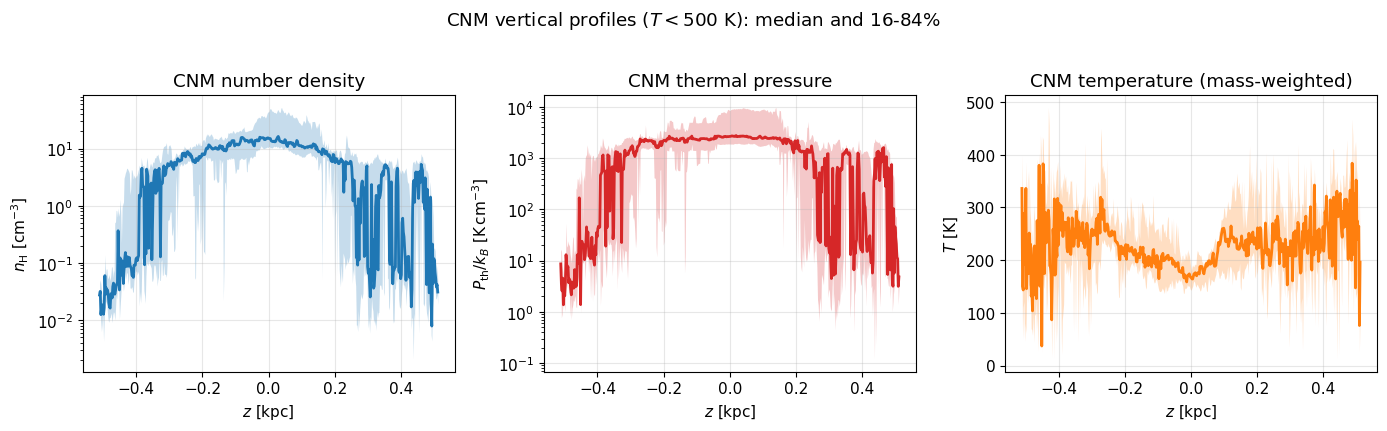

In [3]:
def plot_band(ax, stat, name, zkpc, color="C0", logy=False, label=None):
    # median line + shaded 16-84 percentile band vs height (z on the x-axis)
    med = stat[name].sel(quantile=0.50)
    lo = stat[name].sel(quantile=0.16)
    hi = stat[name].sel(quantile=0.84)
    ax.fill_between(zkpc, lo, hi, color=color, alpha=0.25, lw=0)
    ax.plot(zkpc, med, color=color, lw=2, label=label)
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel(r"$z\ [{\rm kpc}]$")
    ax.grid(alpha=0.3)
    return ax


fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True)

plot_band(axes[0], stat, "nH", zkpc, color="C0", logy=True)
axes[0].set_ylabel(r"$n_{\rm H}\ [{\rm cm^{-3}}]$")
axes[0].set_title("CNM number density")

plot_band(axes[1], stat, "Pth", zkpc, color="C3", logy=True)
axes[1].set_ylabel(r"$P_{\rm th}/k_B\ [{\rm K\,cm^{-3}}]$")
axes[1].set_title("CNM thermal pressure")

plot_band(axes[2], stat, "T", zkpc, color="C1")
axes[2].set_ylabel(r"$T\ [{\rm K}]$")
axes[2].set_title("CNM temperature (mass-weighted)")

fig.suptitle(r"CNM vertical profiles ($T<500$ K): median and 16-84%", y=1.02)
fig.tight_layout()
savefig(fig, "cnm_thermodynamic_profiles.png")

## 5. Velocity dispersions and the effective velocity dispersion

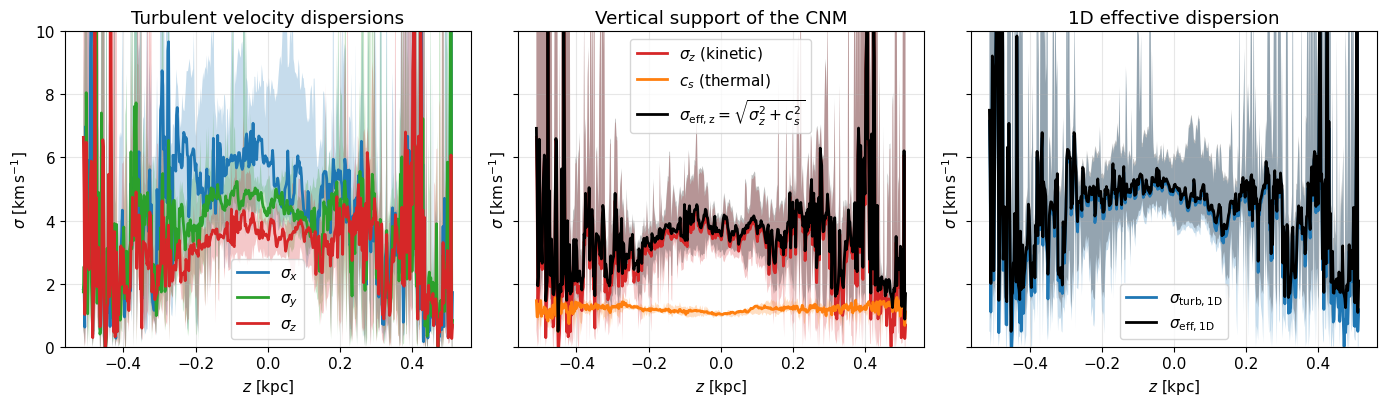

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True, sharey=True)

# (a) the three turbulent components
for name, color, lab in [("sigma_x", "C0", r"$\sigma_x$"),
                         ("sigma_y", "C2", r"$\sigma_y$"),
                         ("sigma_z", "C3", r"$\sigma_z$")]:
    plot_band(axes[0], stat, name, zkpc, color=color, label=lab)
axes[0].set_ylabel(r"$\sigma\ [{\rm km\,s^{-1}}]$")
axes[0].set_title("Turbulent velocity dispersions")
axes[0].legend()

# (b) thermal vs kinetic vs effective (vertical)
plot_band(axes[1], stat, "sigma_z", zkpc, color="C3", label=r"$\sigma_z$ (kinetic)")
plot_band(axes[1], stat, "cs", zkpc, color="C1", label=r"$c_s$ (thermal)")
plot_band(axes[1], stat, "sigma_eff_z", zkpc, color="k",
          label=r"$\sigma_{\rm eff,z}=\sqrt{\sigma_z^2+c_s^2}$")
axes[1].set_ylabel(r"$\sigma\ [{\rm km\,s^{-1}}]$")
axes[1].set_title("Vertical support of the CNM")
axes[1].legend()

# (c) 1D effective dispersion
plot_band(axes[2], stat, "sigma_turb_1D", zkpc, color="C0",
          label=r"$\sigma_{\rm turb,1D}$")
plot_band(axes[2], stat, "sigma_eff_1D", zkpc, color="k",
          label=r"$\sigma_{\rm eff,1D}$")
axes[2].set_ylabel(r"$\sigma\ [{\rm km\,s^{-1}}]$")
axes[2].set_title("1D effective dispersion")
axes[2].legend()

for ax in axes:
    ax.set_ylim(0, 10)  # focus on the CNM range; fast fountain tails clipped

fig.tight_layout()
savefig(fig, "cnm_velocity_dispersions.png")

## 6. CNM area filling fraction and mass fraction

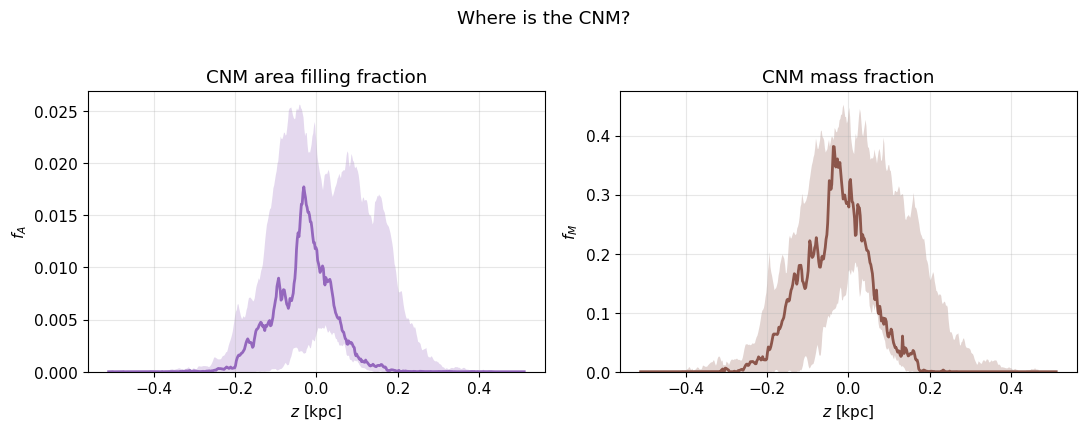

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)

plot_band(axes[0], stat, "f_A", zkpc, color="C4")
axes[0].set_ylabel(r"$f_A$")
axes[0].set_title("CNM area filling fraction")
axes[0].set_ylim(0, None)

plot_band(axes[1], stat, "f_M", zkpc, color="C5")
axes[1].set_ylabel(r"$f_M$")
axes[1].set_title("CNM mass fraction")
axes[1].set_ylim(0, None)

fig.suptitle("Where is the CNM?", y=1.02)
fig.tight_layout()
savefig(fig, "cnm_filling_mass_fraction.png")

## 7. Vertical extent of the CNM layer ($f_M > 1\%$)

We locate the **CNM layer** as the range of heights where the mass fraction
exceeds a threshold, $f_M(z) > f_{M,\rm thr}$ with $f_{M,\rm thr}=1\%$.  For each
snapshot we take the outermost crossings,

$$
z_{\rm bot} = \min\{z: f_M(z) > f_{M,\rm thr}\},\qquad
z_{\rm top} = \max\{z: f_M(z) > f_{M,\rm thr}\},
$$

and define the layer thickness $\Delta z_{\rm CNM} = z_{\rm top}-z_{\rm bot}$.
These trace how the cold layer breathes in time.

In [6]:
FTHR = 0.01  # 1% mass-fraction threshold defining the CNM layer

fM = comb["f_M"].values                  # (n_snap, n_z)
zk = comb["z"].values / 1e3              # height [kpc]
tt = np.asarray(comb["t_Myr"].values)    # time [Myr]

above = fM > FTHR                         # NaN planes -> False automatically
zbot = np.full(fM.shape[0], np.nan)
ztop = np.full(fM.shape[0], np.nan)
for i in range(fM.shape[0]):
    zi = zk[above[i]]
    if zi.size:
        zbot[i], ztop[i] = zi.min(), zi.max()
thick = ztop - zbot                       # layer thickness [kpc]

print(f"CNM layer (f_M > {FTHR:.0%}) across {fM.shape[0]} snapshots:")
print(f"  z_bot     median = {np.nanmedian(zbot):+.3f} kpc")
print(f"  z_top     median = {np.nanmedian(ztop):+.3f} kpc")
print(f"  thickness median = {np.nanmedian(thick):.3f} kpc "
      f"(16-84%: {np.nanpercentile(thick, 16):.3f}-{np.nanpercentile(thick, 84):.3f})")

CNM layer (f_M > 1%) across 11 snapshots:
  z_bot     median = -0.269 kpc
  z_top     median = +0.171 kpc
  thickness median = 0.432 kpc (16-84%: 0.249-0.814)


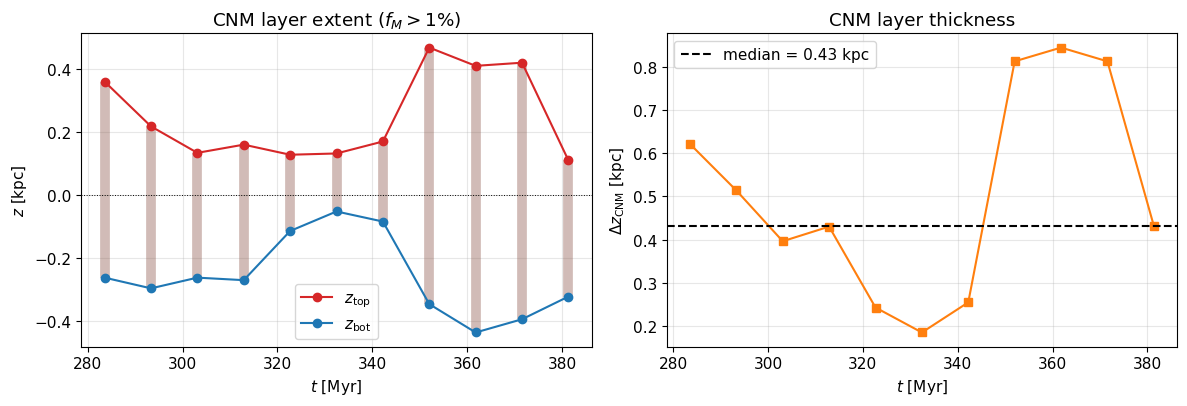

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# (a) per-snapshot extent of the f_M>1% region vs time
axes[0].vlines(tt, zbot, ztop, color="C5", lw=7, alpha=0.4)
axes[0].plot(tt, ztop, "o-", color="C3", label=r"$z_{\rm top}$")
axes[0].plot(tt, zbot, "o-", color="C0", label=r"$z_{\rm bot}$")
axes[0].axhline(0, color="k", lw=0.7, ls=":")
axes[0].set_xlabel(r"$t\ [{\rm Myr}]$")
axes[0].set_ylabel(r"$z\ [{\rm kpc}]$")
axes[0].set_title(r"CNM layer extent ($f_M>1\%$)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# (b) layer thickness vs time
axes[1].plot(tt, thick, "s-", color="C1")
axes[1].axhline(np.nanmedian(thick), color="k", ls="--",
                label=f"median = {np.nanmedian(thick):.2f} kpc")
axes[1].set_xlabel(r"$t\ [{\rm Myr}]$")
axes[1].set_ylabel(r"$\Delta z_{\rm CNM}\ [{\rm kpc}]$")
axes[1].set_title("CNM layer thickness")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, "cnm_layer_extent_vs_time.png")

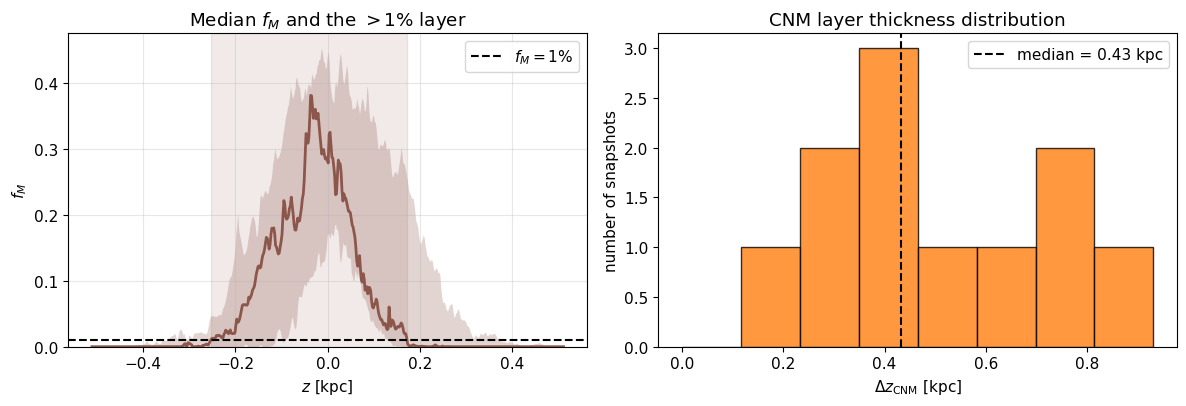

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# (a) median f_M profile with the 1% threshold and the median >1% region shaded
med = stat["f_M"].sel(quantile=0.50)
axes[0].fill_between(zkpc, stat["f_M"].sel(quantile=0.16),
                     stat["f_M"].sel(quantile=0.84), color="C5", alpha=0.25, lw=0)
axes[0].plot(zkpc, med, color="C5", lw=2)
axes[0].axhline(FTHR, color="k", ls="--", label=r"$f_M=1\%$")
zk_arr = np.asarray(zkpc)
regm = np.asarray(med) > FTHR
if regm.any():
    axes[0].axvspan(zk_arr[regm].min(), zk_arr[regm].max(), color="C5", alpha=0.12)
axes[0].set_xlabel(r"$z\ [{\rm kpc}]$")
axes[0].set_ylabel(r"$f_M$")
axes[0].set_title(r"Median $f_M$ and the $>1\%$ layer")
axes[0].set_ylim(0, None)
axes[0].legend()
axes[0].grid(alpha=0.3)

# (b) distribution of the layer thickness across snapshots
axes[1].hist(thick[np.isfinite(thick)],
             bins=np.linspace(0, np.nanmax(thick) * 1.1 + 1e-6, 9),
             color="C1", edgecolor="k", alpha=0.8)
axes[1].axvline(np.nanmedian(thick), color="k", ls="--",
                label=f"median = {np.nanmedian(thick):.2f} kpc")
axes[1].set_xlabel(r"$\Delta z_{\rm CNM}\ [{\rm kpc}]$")
axes[1].set_ylabel("number of snapshots")
axes[1].set_title("CNM layer thickness distribution")
axes[1].legend()

fig.tight_layout()
savefig(fig, "cnm_layer_thickness.png")

## 8. Vertical profiles within the mean CNM layer

We now zoom into the **mean CNM layer** — the height range between the
snapshot-averaged boundaries $\langle z_{\rm bot}\rangle$ and
$\langle z_{\rm top}\rangle$ obtained in section 7 — and show each profile there
with a proper $y$-range (auto-scaled to the data inside the layer).  For every
quantity we overplot the **median** (solid) and the **mean** (dashed) across
snapshots, with the **16-84 percentile** range shaded.

mean CNM layer: z = -0.257 .. +0.247 kpc (thickness 0.504 kpc)


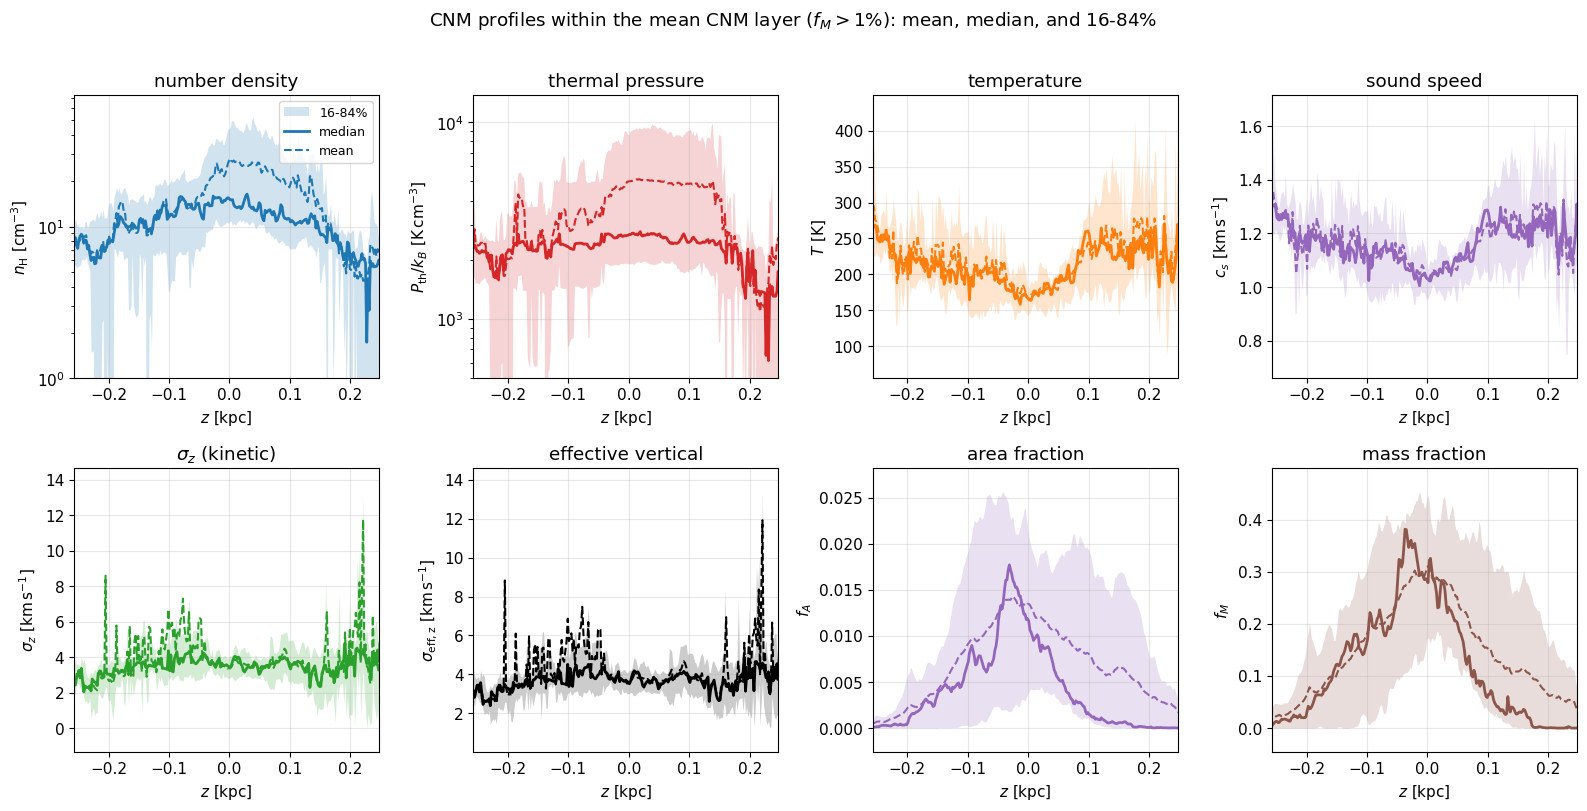

In [9]:
# snapshot-mean profile (companion to the median/percentiles in `stat`)
meands = comb.mean(dim="ivtk", skipna=True)

# the "mean CNM layer": average boundaries from section 7
zL = float(np.nanmean(zbot))   # mean layer bottom [kpc]
zH = float(np.nanmean(ztop))   # mean layer top    [kpc]
zsel = (np.asarray(zkpc) >= zL) & (np.asarray(zkpc) <= zH)
print(f"mean CNM layer: z = {zL:+.3f} .. {zH:+.3f} kpc (thickness {zH - zL:.3f} kpc)")


def plot_layer(ax, name, color="C0", logy=False, title="", ylabel="", ymin=None):
    # median (solid) + mean (dashed) + 16-84 band, restricted to the mean layer
    med = stat[name].sel(quantile=0.50)
    lo = stat[name].sel(quantile=0.16)
    hi = stat[name].sel(quantile=0.84)
    mean = meands[name]
    ax.fill_between(zkpc, lo, hi, color=color, alpha=0.20, lw=0, label="16-84%")
    ax.plot(zkpc, med, color=color, lw=2, label="median")
    ax.plot(zkpc, mean, color=color, lw=1.5, ls="--", label="mean")
    ax.set_xlim(zL, zH)
    if logy:
        ax.set_yscale("log")
    # proper y-range: fit the band and the mean inside the layer, with padding;
    # a fixed lower bound (ymin) overrides the auto-scaled floor when given.
    vals = np.concatenate([lo.values[zsel], hi.values[zsel], mean.values[zsel]])
    vals = vals[np.isfinite(vals)]
    if vals.size:
        vmax = float(vals.max())
        vmin = ymin if ymin is not None else float(vals.min())
        if logy:
            lo_lim = ymin if ymin is not None else vmin / 1.4
            ax.set_ylim(lo_lim, vmax * 1.4)
        else:
            pad = 0.10 * (vmax - vmin) + 1e-12
            lo_lim = ymin if ymin is not None else vmin - pad
            ax.set_ylim(lo_lim, vmax + pad)
    ax.set_xlabel(r"$z\ [{\rm kpc}]$")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(2, 4, figsize=(16, 8))
plot_layer(axes[0, 0], "nH", "C0", logy=True, ymin=1.0,
           title="number density", ylabel=r"$n_{\rm H}\ [{\rm cm^{-3}}]$")
plot_layer(axes[0, 1], "Pth", "C3", logy=True, ymin=5.0e2,
           title="thermal pressure", ylabel=r"$P_{\rm th}/k_B\ [{\rm K\,cm^{-3}}]$")
plot_layer(axes[0, 2], "T", "C1",
           title="temperature", ylabel=r"$T\ [{\rm K}]$")
plot_layer(axes[0, 3], "cs", "C4",
           title="sound speed", ylabel=r"$c_s\ [{\rm km\,s^{-1}}]$")
plot_layer(axes[1, 0], "sigma_z", "C2",
           title=r"$\sigma_z$ (kinetic)", ylabel=r"$\sigma_z\ [{\rm km\,s^{-1}}]$")
plot_layer(axes[1, 1], "sigma_eff_z", "k",
           title="effective vertical", ylabel=r"$\sigma_{\rm eff,z}\ [{\rm km\,s^{-1}}]$")
plot_layer(axes[1, 2], "f_A", "C4", title="area fraction", ylabel=r"$f_A$")
plot_layer(axes[1, 3], "f_M", "C5", title="mass fraction", ylabel=r"$f_M$")
axes[0, 0].legend(fontsize=9, loc="best")
fig.suptitle(r"CNM profiles within the mean CNM layer ($f_M>1\%$): "
             r"mean, median, and 16-84%", y=1.01)
fig.tight_layout()
savefig(fig, "cnm_layer_profiles.png")

## 9. Notes

* **Weighting.** Densities and pressures are volume-weighted horizontal means over
  cold cells; temperature and all velocity moments are mass-weighted
  ($n_{\rm H}$-weighted).  Both weightings are stored in the NetCDF files
  (`T` is mass-weighted, `T_vw` volume-weighted) so alternative choices are easy.
* **Shear frame.** Only $\delta v_y = v_y + q\Omega x$ (background shear removed) is
  used for the dispersion, so $\sigma_y$ reflects turbulence, not the mean shear.
* **Empty planes.** At large $|z|$ some snapshots contain no CNM in a given plane;
  those enter the profiles as `NaN` and are skipped by the percentile reduction
  (`skipna=True`), while $f_A, f_M\to 0$ there.  The velocity panels are clipped to
  $0$-$10\,\mathrm{km\,s^{-1}}$; a few fast fountain cells at large $|z|$ fall outside.
* **Figure files.** Every figure above is also written to `figures/` as a PNG
  (via the `savefig()` helper defined in section 3).